## 1. Setup Mount & Drive

In [ ]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Path Configuration
BASE_DIR = "/content/drive/MyDrive/skripsi/dataset/mbg"
RAW_DATA_MBG_DIR = os.path.join(BASE_DIR, "raw_data", "mbg")
RAW_DATA_MAKAN_DIR = os.path.join(BASE_DIR, "raw_data", "makan_bergizi_gratis")
MERGED_OUTPUT_DIR = os.path.join(BASE_DIR, "merged_data")

os.makedirs(MERGED_OUTPUT_DIR, exist_ok=True)

print(f"📂 Folder Input MBG   : {RAW_DATA_MBG_DIR}")
print(f"📂 Folder Input Makan : {RAW_DATA_MAKAN_DIR}")
print(f"📂 Folder Output      : {MERGED_OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Folder Input MBG   : /content/drive/MyDrive/skripsi/dataset/mbg/raw_data/mbg
📂 Folder Input Makan : /content/drive/MyDrive/skripsi/dataset/mbg/raw_data/makan_bergizi_gratis
📂 Folder Output      : /content/drive/MyDrive/skripsi/dataset/mbg/merged_data


## 2. Definisi Konstanta & Aturan Filter

In [ ]:
# --- TIMEZONE CONFIGURATION ---
START_DATE = pd.Timestamp("2025-01-06").tz_localize('UTC')
END_DATE   = pd.Timestamp("2026-01-07").tz_localize('UTC')

# --- CONFIGURATION KEYWORDS ---
KEYWORDS_MAKAN = [
    "makan bergizi gratis",
    "makan bergizi",
    "makan siang gratis",
    "program makan gratis"
]
KEYWORDS_MBG = ["mbg"]

# --- SPAM KEYWORDS ---
SPAM_KEYWORDS = [
    # Judi Online
    "slot", "gacor", "zeus", "pragmatic", "maxwin", "wd", "depo",
    "pola gacor", "rtp", "judol", "link daftar", "situs",
    # E-Commerce & Spam Bot
    "shopee", "tokopedia", "lazada", "blibli", "cek keranjang",
    "spaylater", "dana kaget", "giveaway", "racun", "link di bio",
    "affiliate", "open joki", "joki tugas", "jasjok", "convert pulsa",
    "mutualan", "follback", "biro jodoh",
    # Konten Dewasa
    "open bo", "vcs", "video syur", "museum", "boke", "desah", "colmek"
]

# Siapkan regex pattern untuk kecepatan filtering (Vektorisasi Pangdas)
SPAM_REGEX_PATTERN = '|'.join(SPAM_KEYWORDS)

## 3. Fungsi Modular Pipeline Pengolahan

In [ ]:
def load_and_merge_csv(folder_path):
    """
    Reads all CSV files in a given folder and merges them into a single DataFrame.
    """
    all_files = glob.glob(os.path.join(folder_path, "*.csv"))
    if not all_files:
        print(f"⚠️ No files found in {folder_path}")
        return pd.DataFrame()

    df_list = []
    for filepath in all_files:
        try:
            df = pd.read_csv(
                filepath,
                on_bad_lines='skip',
                lineterminator='\n',
                encoding_errors='ignore',
                low_memory=False
            )
            df_list.append(df)
        except Exception as e:
            print(f" ❌ Failed to read {os.path.basename(filepath)}: {e}")

    if not df_list:
        return pd.DataFrame()

    return pd.concat(df_list, ignore_index=True)


def standardize_columns(df):
    """
    Standardizes column names and normalizes corrupted anomalies (like username).
    """
    # Rename default mapping (tidak menyentuh id_str yang sudah ada dari raw data!)
    col_mapping = {'date': 'created_at', 'text': 'full_text'}
    df.rename(columns=col_mapping, inplace=True, errors='ignore')

    # Normalize username columns caused by crawling parse error
    anomaly_cols = ['username', 'username\r', 'username;;;;;;;\r']

    # Ensure primary username exists
    if 'username' not in df.columns:
        df['username'] = pd.NA

    # Coalesce via combine_first using vectors
    for col in anomaly_cols:
        if col in df.columns and col != 'username':
            df[col] = df[col].replace(r'^\s*$', pd.NA, regex=True)
            df['username'] = df['username'].replace(r'^\s*$', pd.NA, regex=True)
            df['username'] = df['username'].combine_first(df[col])

    # Drop dropped anomaly columns to clean the dataset
    cols_to_drop = [c for c in anomaly_cols if c != 'username']
    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    # --- VALIDASI id_str ---
    # Memastikan kolom 'id_str' asli murni tetap string dan tidak menjadi NaN
    if 'id_str' in df.columns:
        df['id_str'] = df['id_str'].astype(str)
        df['id_str'] = df['id_str'].replace(r'\.?0$', '', regex=True) # antisipasi float bypass
        df.loc[df['id_str'].isin(['nan', '<NA>']), 'id_str'] = ''
    else:
        print("   ⚠️ Warning: Kolom 'id_str' tidak ditemukan!")
        df['id_str'] = ''

    return df


def filter_by_required_keywords(df, required_keywords):
    """
    Filters rows ensuring the full_text contains at least one of the required keywords.
    """
    pattern = '|'.join(required_keywords)
    mask = df['full_text'].astype(str).str.contains(pattern, case=False, na=False)
    return df[mask].copy()


def filter_by_date(df, start_date, end_date):
    """
    Transforms the date column to timezone-aware UTC and filters by date range.
    """
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce', format='mixed', utc=True)
    df.dropna(subset=['created_at'], inplace=True)
    mask = (df['created_at'] >= start_date) & (df['created_at'] < end_date)
    return df[mask].copy()


def remove_id_duplicates(df):
    """
    Menghapus duplikasi absolut berdasarkan Primary Key (id_str).
    """
    df = df[df['id_str'] != '']
    df.drop_duplicates(subset=['id_str'], keep='first', inplace=True)
    return df


def remove_advanced_duplicates(df):
    """
    Aggressively removes duplicates by ignoring URLs, mentions, hashtags, and punctuations.
    """
    temp_series = df['full_text'].astype(str).str.lower()
    temp_series = temp_series.str.replace(r'http\S+|www\S+|https\S+', '', regex=True)
    temp_series = temp_series.str.replace(r'@\w+', '', regex=True)
    temp_series = temp_series.str.replace(r'#\w+', '', regex=True)
    temp_series = temp_series.str.replace(r'[^\w\s]', '', regex=True)
    temp_series = temp_series.str.replace(r'\s+', ' ', regex=True).str.strip()

    df['temp_dedup'] = temp_series

    df = df[df['temp_dedup'] != '']
    df.drop_duplicates(subset=['temp_dedup'], keep='first', inplace=True)
    df.drop(columns=['temp_dedup'], inplace=True)

    return df


def remove_spam(df):
    """
    Filters out spam rows relying on predefined spam keywords.
    """
    is_spam_mask = df['full_text'].astype(str).str.contains(SPAM_REGEX_PATTERN, case=False, na=False)
    return df[~is_spam_mask].copy()


def process_pipeline(folder_path, source_label, required_keywords):
    """
    The main coordinator function executing the established data processing pipeline.
    """
    print(f"\n🚀 Processing Folder: {source_label} ...")

    # 1. Load Data
    df = load_and_merge_csv(folder_path)
    if df.empty:
        return df

    initial_count = len(df)
    print(f"   📥 Total Raw Data    : {initial_count} rows")

    # 2. Standardize & Fix Anomalies (termasuk validasi id_str asli)
    df = standardize_columns(df)
    if 'full_text' not in df.columns or 'created_at' not in df.columns:
        print("   ❌ Error: 'full_text' or 'created_at' column missing.")
        return pd.DataFrame()

    # 3. Filter Keywords
    df = filter_by_required_keywords(df, required_keywords)
    print(f"   🔍 Keyword Mismatch : {initial_count - len(df)} rows dropped")
    keyword_filtered_count = len(df)

    # 4. Filter Date Range
    df = filter_by_date(df, START_DATE, END_DATE)
    print(f"   📅 Out of Date Range : {keyword_filtered_count - len(df)} rows dropped")
    date_filtered_count = len(df)

    # 5. Remove Duplicates (By ID + Advanced Text)
    df = remove_id_duplicates(df)
    print(f"   🆔 Duplicates by ID  : {date_filtered_count - len(df)} rows dropped")
    id_dedup_count = len(df)

    df = remove_advanced_duplicates(df)
    print(f"   ♻️  Duplicates by Text: {id_dedup_count - len(df)} rows dropped (Advanced)")
    dedup_count = len(df)

    # 6. Remove Spam
    df = remove_spam(df)
    print(f"   🗑️  Spam Removed      : {dedup_count - len(df)} rows")

    # 7. Finalization
    df.sort_values(by='created_at', ascending=True, inplace=True)
    df['source_keyword'] = source_label

    print(f"   ✨ FINAL VALID DATA  : {len(df)} rows")
    return df

## 4. Eksekusi Penggabungan Keseluruhan (Full Merge & Save)

In [ ]:
# 1. Eksekusi Program Makan Bergizi
df_makan = process_pipeline(RAW_DATA_MAKAN_DIR, "makan_bergizi_gratis", KEYWORDS_MAKAN)

# 2. Eksekusi MBG
df_mbg = process_pipeline(RAW_DATA_MBG_DIR, "mbg", KEYWORDS_MBG)

# 3. Penggabungan Menjadi Merged Full Dataset
df_full = pd.concat([df_makan, df_mbg], axis=0, ignore_index=True)

# --- ELIMINASI DUPLIKASI LINTAS-DATASET ---
# Menghapus jika crawling 'makan bergizi gratis' merekam cuitan yang sama dengan 'mbg'
duplicate_count_id = df_full.duplicated(subset=['id_str']).sum()
if duplicate_count_id > 0:
    df_full.drop_duplicates(subset=['id_str'], keep='first', inplace=True)
    print(f"✨ Penggabungan Data: Duplikat ID dihapus sejumlah {duplicate_count_id} baris.")

duplicate_count_text = df_full.duplicated(subset=['full_text']).sum()
if duplicate_count_text > 0:
    df_full.drop_duplicates(subset=['full_text'], keep='first', inplace=True)
    print(f"✨ Penggabungan Data: Duplikat Teks utuh dihapus sejumlah {duplicate_count_text} baris.")

print(f"\n✅ DATA MERGE FINAL YANG SIAP DISIMPAN: {len(df_full)} baris")

# 4. Simpan Data Tiga File Output
output_makan_path = os.path.join(MERGED_OUTPUT_DIR, "merged_makan_bergizi_gratis.csv")
output_mbg_path = os.path.join(MERGED_OUTPUT_DIR, "merged_mbg.csv")
output_full_path = os.path.join(MERGED_OUTPUT_DIR, "merged_mbg_full.csv")

if not df_makan.empty:
    df_makan.to_csv(output_makan_path, index=False)
    print(f"\n💾 Saved Part 1: {output_makan_path}")

if not df_mbg.empty:
    df_mbg.to_csv(output_mbg_path, index=False)
    print(f"💾 Saved Part 2: {output_mbg_path}")

if not df_full.empty:
    df_full.to_csv(output_full_path, index=False)
    print(f"💾 Saved Merged Full: {output_full_path}")


🚀 Processing Folder: makan_bergizi_gratis ...
   📥 Total Raw Data    : 70075 rows
   🔍 Keyword Mismatch : 4998 rows dropped
   📅 Out of Date Range : 0 rows dropped
   🆔 Duplicates by ID  : 5153 rows dropped
   ♻️  Duplicates by Text: 14556 rows dropped (Advanced)
   🗑️  Spam Removed      : 3435 rows
   ✨ FINAL VALID DATA  : 41933 rows

🚀 Processing Folder: mbg ...
   📥 Total Raw Data    : 101934 rows
   🔍 Keyword Mismatch : 5375 rows dropped
   📅 Out of Date Range : 234 rows dropped
   🆔 Duplicates by ID  : 2246 rows dropped
   ♻️  Duplicates by Text: 5314 rows dropped (Advanced)
   🗑️  Spam Removed      : 8081 rows
   ✨ FINAL VALID DATA  : 80684 rows
✨ Penggabungan Data: Duplikat ID dihapus sejumlah 3230 baris.
✨ Penggabungan Data: Duplikat Teks utuh dihapus sejumlah 7 baris.

✅ DATA MERGE FINAL YANG SIAP DISIMPAN: 119380 baris

💾 Saved Part 1: /content/drive/MyDrive/skripsi/dataset/mbg/merged_data/merged_makan_bergizi_gratis.csv
💾 Saved Part 2: /content/drive/MyDrive/skripsi/dataset

## 5. Preview & Informasi Dataset Lengkap

In [ ]:
print("\n===== INFORMASI DATASET =====")

# Kolom
print("\nKolom dalam dataset:")
print(df_full.columns.tolist())

# Info umum
print("\nInfo dataset:")
df_full.info()

# Total data
print("\nTotal jumlah data terverifikasi:", len(df_full))

# Missing values
print("\nJumlah missing values per kolom:")
print(df_full.isnull().sum())

print("\n📊 HASIL AKHIR PERSEBARAN DATA BERDASARKAN KEYWORD:")
mbg_count = len(df_full[df_full['source_keyword'] == 'mbg'])
makan_count = len(df_full[df_full['source_keyword'] == 'makan_bergizi_gratis'])
print(f"   🔸 Keyword 'MBG'                     : {mbg_count} baris")
print(f"   🔸 Keyword 'makan bergizi gratis'    : {makan_count} baris")


===== INFORMASI DATASET =====

Kolom dalam dataset:
['conversation_id_str', 'created_at', 'favorite_count', 'full_text', 'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location', 'quote_count', 'reply_count', 'retweet_count', 'tweet_url', 'user_id_str', 'username', 'source_keyword']

Info dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 119380 entries, 0 to 122616
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype              
---  ------                   --------------   -----              
 0   conversation_id_str      119380 non-null  int64              
 1   created_at               119380 non-null  datetime64[ns, UTC]
 2   favorite_count           119380 non-null  int64              
 3   full_text                119380 non-null  object             
 4   id_str                   119380 non-null  object             
 5   image_url                44624 non-null   object             
 6   in_reply_to_screen_name  48378 non-null  

In [ ]:
print("\n===== 5 DATA AWAL =====")
display(df_full.head(5))


===== 5 DATA AWAL =====


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,source_keyword
0,1876182338910249218,2025-01-06 08:21:42+00:00,1,Menpora Dito Kawal Langsung Program Prioritas ...,1876182338910249218,https://pbs.twimg.com/media/GgmJ5JxWcAApJi6.jpg,NaN,in,NaN,0,0,1,https://x.com/aula_media/status/18761823389102...,1278217985795096576,aula_media\r,makan_bergizi_gratis
1,1876164975364104315,2025-01-06 08:22:02+00:00,0,@Mata_Netizen62 Untuk kali ini saya dukung PBN...,1876182425283563967,NaN,Mata_Netizen62,in,NaN,0,0,0,https://x.com/RizalFauzan6/status/187618242528...,786088394,RizalFauzan6\r,makan_bergizi_gratis
2,1876182704703832175,2025-01-06 08:23:09+00:00,0,Program Makan Bergizi Gratis Bergulir di Banja...,1876182704703832175,NaN,NaN,in,NaN,0,0,0,https://x.com/banjarmasinpost/status/187618270...,65639033,banjarmasinpost\r,makan_bergizi_gratis
3,1876182747422867738,2025-01-06 08:23:19+00:00,0,🍱 Program Makan Bergizi Gratis Resmi Dimulai! ...,1876182747422867738,https://pbs.twimg.com/media/GgmKMilboAAAxq_.jpg,NaN,in,NaN,0,0,0,https://x.com/FMB9ID_/status/1876182747422867738,902385054336167937,FMB9ID_\r,makan_bergizi_gratis
4,1876183080857424006,2025-01-06 08:24:38+00:00,9,Hari ke-78 pemerintahan @prabowo dan @gibran_t...,1876183080857424006,https://pbs.twimg.com/media/GgmKkKyakAA3DZs.jpg,NaN,in,NaN,0,5,7,https://x.com/griselruiz88/status/187618308085...,1072577966,griselruiz88\r,makan_bergizi_gratis


In [ ]:
print("\n===== 5 DATA AKHIR =====")
display(df_full.tail(5))


===== 5 DATA AKHIR =====


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,source_keyword
122612,2008383167531806765,2026-01-06 23:55:02+00:00,5,"@dyahNeZza Spt jajan di warung aja, ga ada yg ...",2008688790844698817,NaN,dyahNeZza,in,NaN,0,17,0,https://x.com/Roni34ndri/status/20086887908446...,1649083147718631425,Roni34ndri\r,mbg
122613,2008518426705490000,2026-01-06 23:55:27+00:00,0,@arindraaa @BigAlphaID MBG libur kan duitnya b...,2008688895970746469,NaN,arindraaa,in,NaN,0,0,0,https://x.com/ibiz4/status/2008688895970746469,830258112,ibiz4\r,mbg
122614,2008689473237012657,2026-01-06 23:57:44+00:00,1,"Makan bergizi, generasi prestasi! Dukung Progr...",2008689473237012657,https://pbs.twimg.com/media/G-BMbkSa8AAOLgk.jpg,NaN,in,NaN,0,4,0,https://x.com/vonnyfelicia4/status/20086894732...,1565711358880268289,vonnyfelicia4\r,mbg
122615,2008154600466194556,2026-01-06 23:58:56+00:00,0,@BBCIndonesia MBG hadir gak?,2008689773586903399,NaN,BBCIndonesia,in,NaN,0,0,0,https://x.com/widi_211/status/2008689773586903399,761674910,widi_211\r,mbg
122616,2008458460770562538,2026-01-06 23:59:48+00:00,0,@mhuseinali Kerja Nyata MBG dan ketring di lap...,2008689992898629661,NaN,mhuseinali,in,NaN,0,0,0,https://x.com/Rudy_muham4d/status/200868999289...,1717865359557177344,Rudy_muham4d\r,mbg


## 6. Visualisasi Data

In [ ]:
def plot_timeline(df_list, labels):
    plt.figure(figsize=(15, 6))

    for df, label in zip(df_list, labels):
        if df.empty: continue
        daily_counts = df.set_index('created_at').resample('D').size()
        plt.plot(daily_counts.index, daily_counts.values, label=f"{label}", alpha=0.8)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=14))

    plt.title("Daily Tweet Volume Trend")
    plt.xlabel("Date")
    plt.ylabel("Number of Tweets")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_monthly(df_list, labels):
    combined_monthly = pd.DataFrame()

    for df, label in zip(df_list, labels):
        if df.empty: continue
        monthly_counts = df.set_index('created_at').resample('M', kind='period').size()

        # Konversi index period menjadi stamp awal bulan hanya untuk charting string
        monthly_counts.index = monthly_counts.index.strftime('%b %y')
        combined_monthly[label] = monthly_counts

    if combined_monthly.empty:
        print("⚠️ No data available for monthly chart.")
        return

    ax = combined_monthly.plot(kind='bar', figsize=(12, 6), width=0.8, alpha=0.85)

    plt.title("Monthly Tweet Volume Trend")
    plt.xlabel("Month")
    plt.ylabel("Number of Tweets")
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.legend()

    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0:
            ax.annotate(str(int(height)), (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=9)

    plt.tight_layout()
    plt.show()


📊 Menampilkan Tren Keseluruhan Dataset Tergabung (Merged Full):



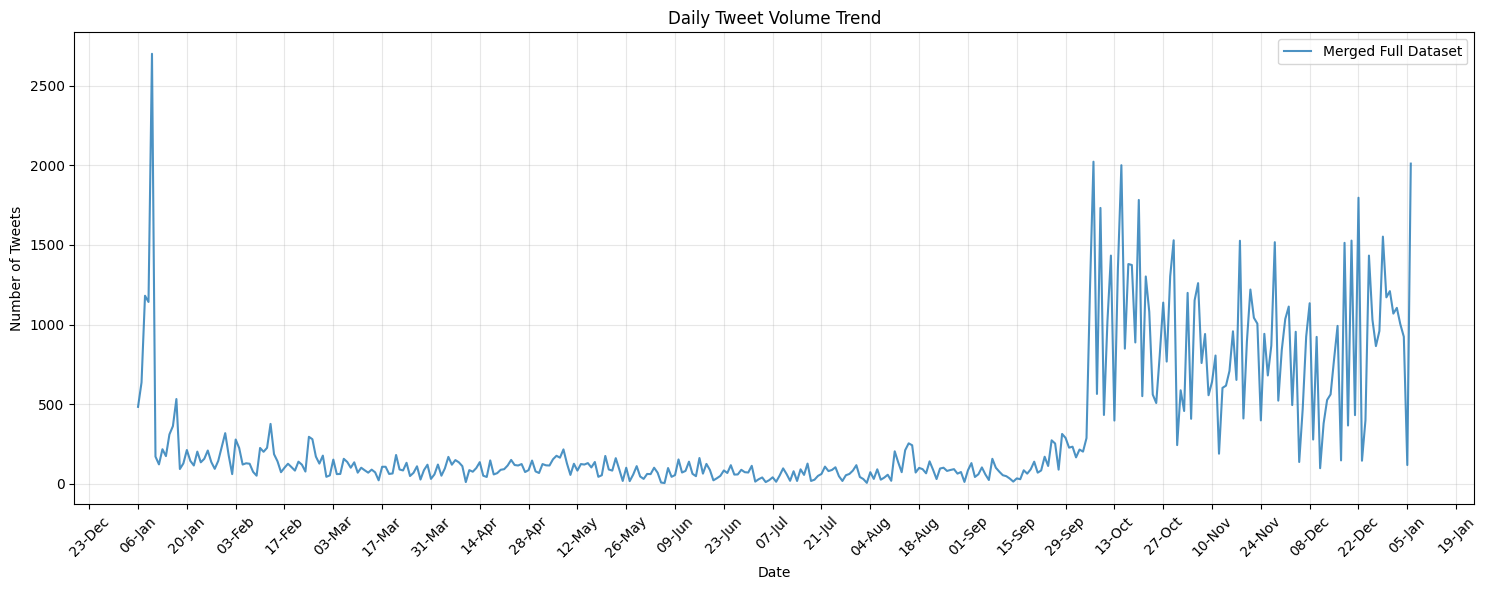

/tmp/ipykernel_1426/2458568186.py:26: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  monthly_counts = df.set_index('created_at').resample('M', kind='period').size()
/tmp/ipykernel_1426/2458568186.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df.set_index('created_at').resample('M', kind='period').size()


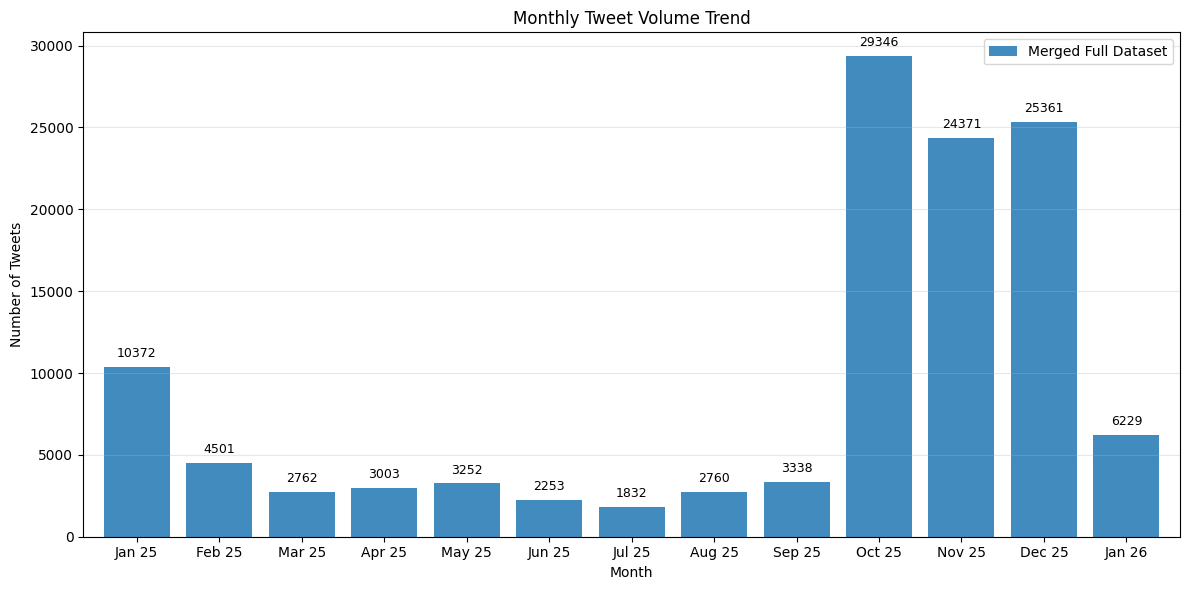

In [ ]:
# Detail Full Dataset
print("\n📊 Menampilkan Tren Keseluruhan Dataset Tergabung (Merged Full):\n")
plot_timeline([df_full], ['Merged Full Dataset'])
plot_monthly([df_full], ['Merged Full Dataset'])


📊 Menampilkan Tren Keseluruhan Dataset Keyword 'MBG' dan Keyword 'Makan Bergizi Gratis':



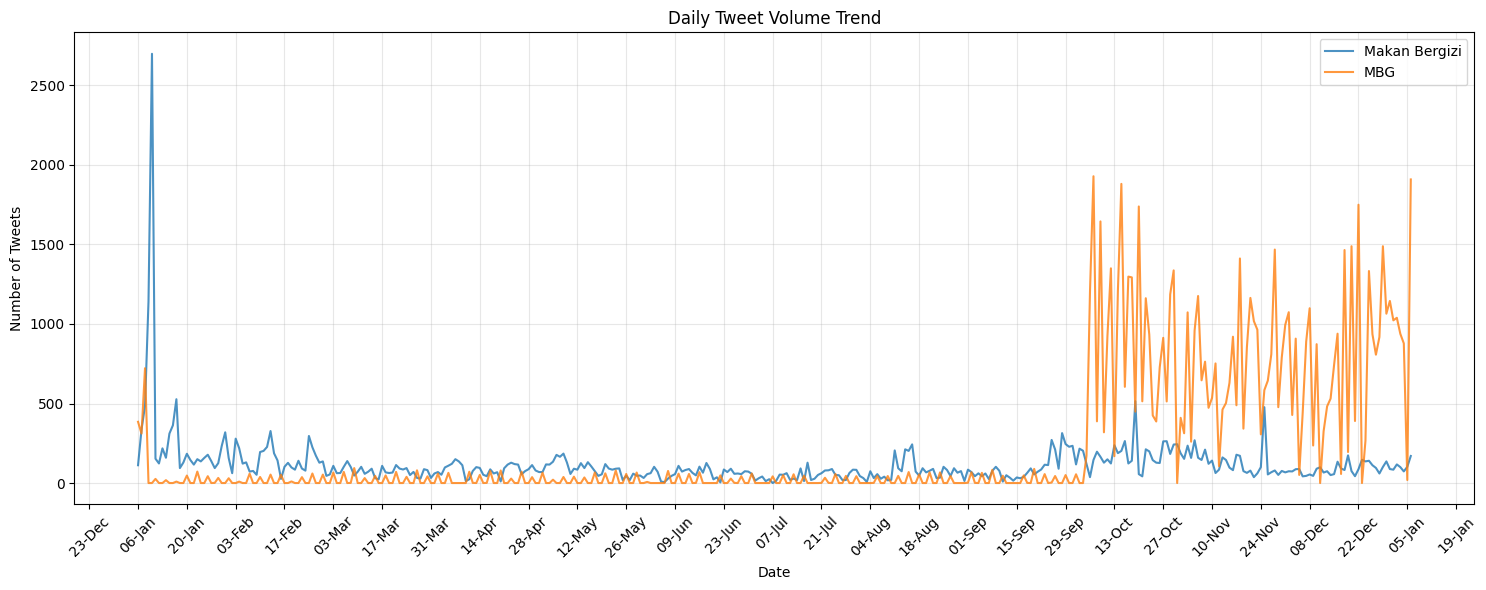

/tmp/ipykernel_1426/2458568186.py:26: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  monthly_counts = df.set_index('created_at').resample('M', kind='period').size()
/tmp/ipykernel_1426/2458568186.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df.set_index('created_at').resample('M', kind='period').size()
/tmp/ipykernel_1426/2458568186.py:26: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  monthly_counts = df.set_index('created_at').resample('M', kind='period').size()
/tmp/ipykernel_1426/2458568186.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df.set_index('created_at').resample('M', kind='period')

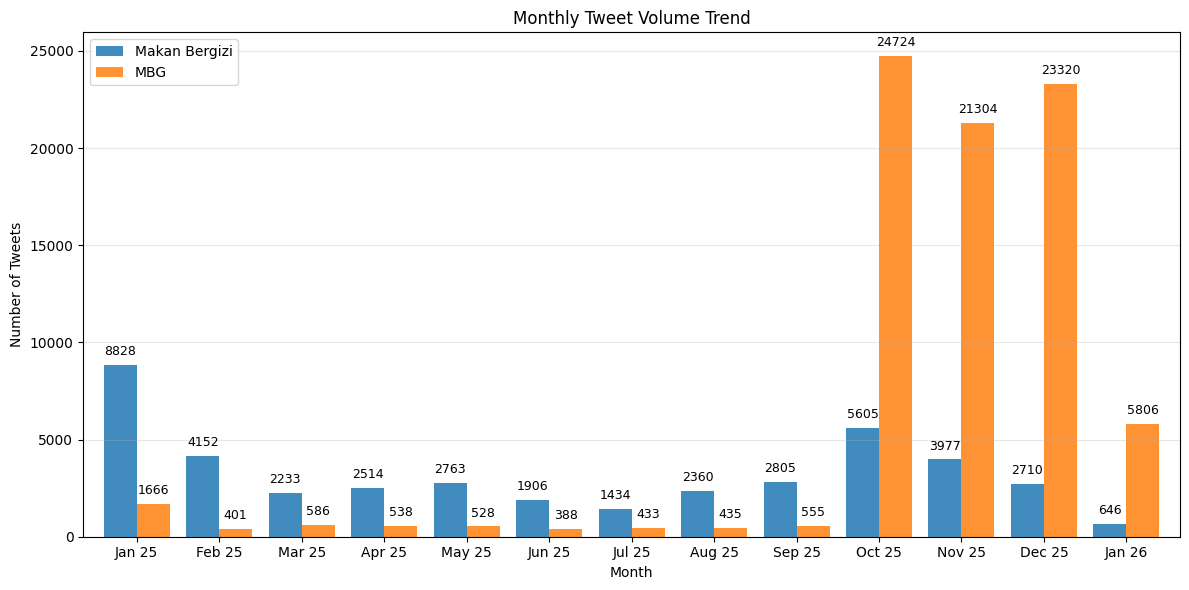

In [ ]:
# Detail Dataset Keyword 1 dan 2
print("\n📊 Menampilkan Tren Keseluruhan Dataset Keyword 'MBG' dan Keyword 'Makan Bergizi Gratis':\n")
plot_timeline([df_makan, df_mbg], ['Makan Bergizi', 'MBG'])
plot_monthly([df_makan, df_mbg], ['Makan Bergizi', 'MBG'])